# Phase 3 — Exploratory Data Analysis (EDA)
## Global Food Security Risk Analysis

**Objective:** Explore the merged dataset to understand distributions, missing value patterns, correlations, regional differences, time trends, and country risk clusters.

**Dataset:** `data/processed/merged_final.csv`
- Shape: (2599, 18)
- Countries: 200
- Years: 2010–2022

**Target Variable:** `undernourishment_pct` — Percentage of population that is undernourished

---
**EDA Steps:**
1. Data Loading & Basic Statistics
2. Target Variable Distribution
3. Missing Value Analysis
4. Correlation Analysis
5. Country & Regional Comparison
6. Time Series Trends
7. Feature vs Target Scatter Plots
8. Deep Dive 1 — Outlier Impact Analysis
9. Deep Dive 2 — Country Risk Clustering
10. Deep Dive 3 — COVID-19 Impact Analysis


## Step 1 — Data Loading & Basic Statistics

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Plot settings
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
sns.set_theme(style='whitegrid')

print("Libraries loaded ✅")

Libraries loaded ✅


In [28]:
# Paths
BASE_DIR = Path('..')
DATA_PATH = BASE_DIR / 'data' / 'processed' / 'merged_final.csv'
FIGURES_DIR = BASE_DIR / 'outputs' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Load data
df = pd.read_csv(DATA_PATH)

print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

Shape: (2599, 18)
Columns: ['iso3', 'Area', 'Year', 'undernourishment_pct', 'dietary_energy_supply_kcal', 'food_supply_kcal', 'protein_supply_g', 'fat_supply_g', 'food_supply_variability_kcal', 'cereal_import_dependency_pct', 'agri_production_index', 'food_production_index', 'gdp_per_capita', 'poverty_rate', 'population', 'population_growth_pct', 'precipitation_mm', 'political_stability_index']


In [29]:
# Basic statistics
df.describe().round(2)

,Year,undernourishment_pct,dietary_energy_supply_kcal,food_supply_kcal,protein_supply_g,fat_supply_g,food_supply_variability_kcal,cereal_import_dependency_pct,agri_production_index,food_production_index,gdp_per_capita,poverty_rate,population,population_growth_pct,precipitation_mm,political_stability_index
count,2599.00,2012.00,2179.00,2235.00,2235.00,2235.00,2174.00,2017.00,2027.00,2027.00,2549.00,1038.00,2.586000e+03,2585.00,2360.00,2535.00
mean,2016.00,9.75,2895.72,2910.07,87.67,91.83,34.38,29.37,100.68,100.56,15284.36,7.24,3.764775e+07,1.22,1172.31,-0.07
std,3.74,10.04,443.94,446.80,22.76,36.10,24.69,72.57,12.77,12.90,21224.18,14.94,1.410446e+08,1.54,799.06,0.99
min,2010.00,2.50,1490.00,1810.45,28.28,21.03,1.00,-734.90,41.47,41.47,216.73,0.00,9.992000e+03,-10.93,18.10,-3.13
25%,2013.00,2.50,2583.00,2595.36,68.32,61.58,20.00,8.20,94.60,94.48,2081.74,0.20,1.790729e+06,0.26,562.00,-0.68
50%,2016.00,5.60,2906.00,2902.75,89.80,90.24,29.00,40.20,99.62,99.47,6049.52,1.10,7.573067e+06,1.16,1032.00,0.02
75%,2019.00,13.70,3237.00,3260.32,105.47,119.90,43.00,76.70,105.09,104.91,19151.09,5.90,2.674936e+07,2.20,1712.00,0.78
max,2022.00,72.50,3937.00,3966.57,152.61,188.27,286.00,100.00,222.79,222.79,134965.82,85.30,1.425423e+09,14.23,3240.00,1.96


## Step 2 — Target Variable Distribution

Analyzing the distribution of `undernourishment_pct` to understand its shape and decide whether log-transformation is needed.


Figure already exists, skipping: step2_target_distribution.png


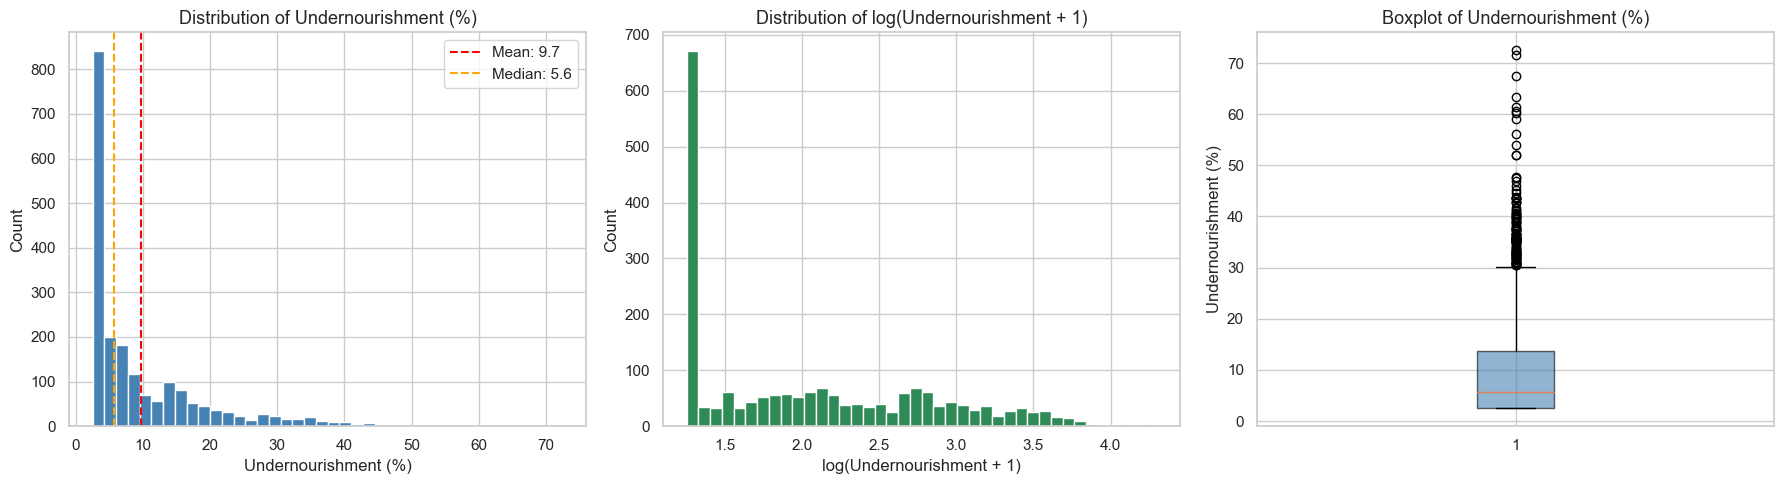

In [30]:
fig_path = FIGURES_DIR / 'step2_target_distribution.png'

if fig_path.exists():
    print(f"Figure already exists, skipping: {fig_path.name}")
    from IPython.display import Image
    display(Image(str(fig_path)))
else:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    target = df['undernourishment_pct'].dropna()

    # Histogram (original)
    axes[0].hist(target, bins=40, color='steelblue', edgecolor='white')
    axes[0].set_title('Distribution of Undernourishment (%)', fontsize=13)
    axes[0].set_xlabel('Undernourishment (%)')
    axes[0].set_ylabel('Count')
    axes[0].axvline(target.mean(), color='red', linestyle='--', label=f'Mean: {target.mean():.1f}')
    axes[0].axvline(target.median(), color='orange', linestyle='--', label=f'Median: {target.median():.1f}')
    axes[0].legend()

    # Histogram (log-transformed)
    axes[1].hist(np.log1p(target), bins=40, color='seagreen', edgecolor='white')
    axes[1].set_title('Distribution of log(Undernourishment + 1)', fontsize=13)
    axes[1].set_xlabel('log(Undernourishment + 1)')
    axes[1].set_ylabel('Count')

    # Boxplot
    axes[2].boxplot(target, vert=True, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6))
    axes[2].set_title('Boxplot of Undernourishment (%)', fontsize=13)
    axes[2].set_ylabel('Undernourishment (%)')

    plt.tight_layout()
    plt.savefig(fig_path, bbox_inches='tight')
    plt.show()
    print("Saved ✅")

In [31]:
from scipy import stats

target = df['undernourishment_pct'].dropna()
skewness = target.skew()
kurtosis = target.kurtosis()

print(f"Count    : {len(target)}")
print(f"Mean     : {target.mean():.2f}%")
print(f"Median   : {target.median():.2f}%")
print(f"Std      : {target.std():.2f}")
print(f"Skewness : {skewness:.3f}  (>1 indicates right skew → log transform recommended)")
print(f"Kurtosis : {kurtosis:.3f}  (heavy tails due to outliers)")
print()
print("Conclusion: Strong right skew (2.037) → log(1+x) transformation will be applied in modeling.")
print("Note: Large spike at low values due to Phase 2 imputation: <2.5% → 2.5")

Count    : 2012
Mean     : 9.75%
Median   : 5.60%
Std      : 10.04
Skewness : 2.037  (>1 indicates right skew → log transform recommended)
Kurtosis : 5.069  (heavy tails due to outliers)

Conclusion: Strong right skew (2.037) → log(1+x) transformation will be applied in modeling.
Note: Large spike at low values due to Phase 2 imputation: <2.5% → 2.5


## Step 3 — Missing Value Analysis

Visualizing missing value rates and patterns to inform data cleaning strategy.


Figure already exists, skipping: step3_missing_values.png


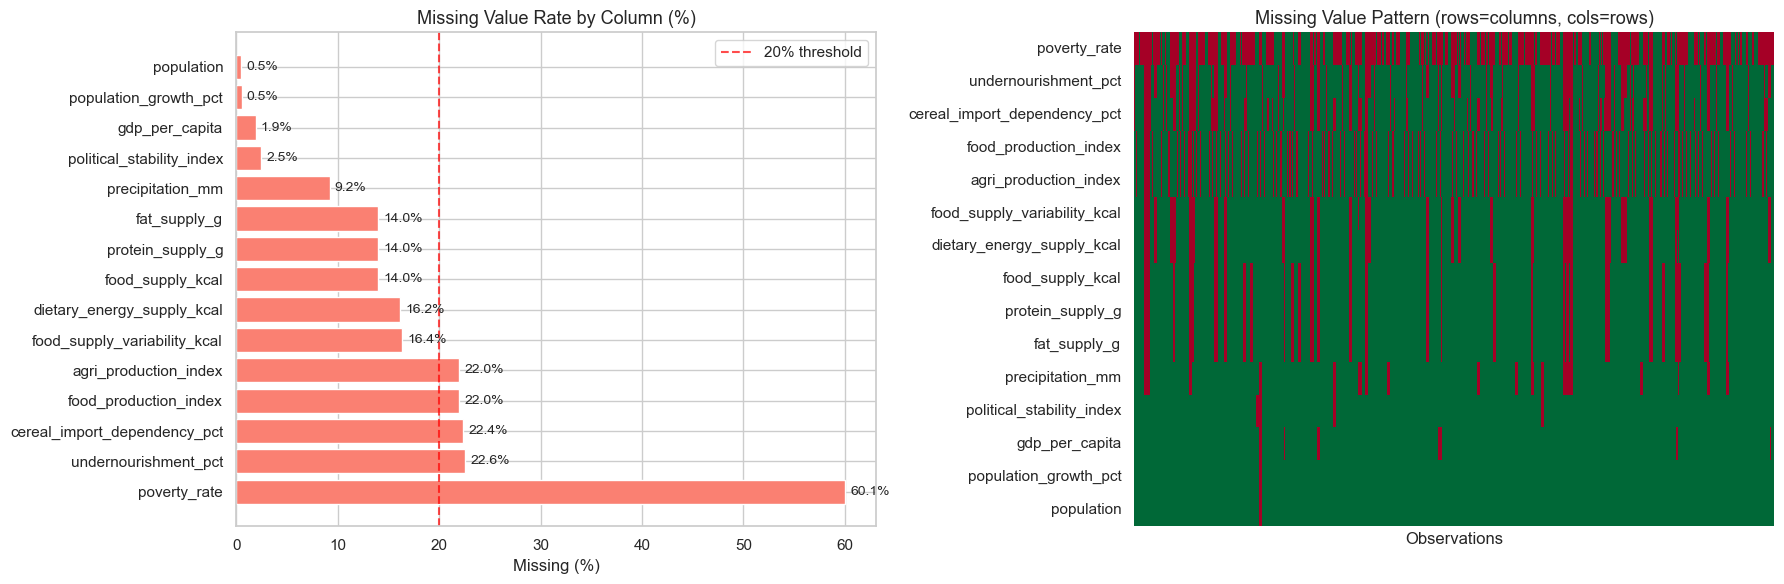

In [32]:
import missingno as msno

fig_path = FIGURES_DIR / 'step3_missing_values.png'

if fig_path.exists():
    print(f"Figure already exists, skipping: {fig_path.name}")
    from IPython.display import Image
    display(Image(str(fig_path)))
else:
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    missing_pct = df.isnull().mean().sort_values(ascending=False) * 100
    missing_pct = missing_pct[missing_pct > 0]

    axes[0].barh(missing_pct.index, missing_pct.values, color='salmon', edgecolor='white')
    axes[0].set_title('Missing Value Rate by Column (%)', fontsize=13)
    axes[0].set_xlabel('Missing (%)')
    axes[0].axvline(20, color='red', linestyle='--', alpha=0.7, label='20% threshold')
    axes[0].legend()
    for i, v in enumerate(missing_pct.values):
        axes[0].text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=10)

    missing_matrix = df[missing_pct.index].isnull()
    sns.heatmap(missing_matrix.T, cmap='RdYlGn_r', cbar=False,
                yticklabels=True, xticklabels=False, ax=axes[1])
    axes[1].set_title('Missing Value Pattern', fontsize=13)
    axes[1].set_xlabel('Observations')

    plt.tight_layout()
    plt.savefig(fig_path, bbox_inches='tight')
    plt.show()
    print("Saved ✅")

In [33]:
missing_summary = pd.DataFrame({
    'missing_count': df.isnull().sum(),
    'missing_pct': (df.isnull().mean() * 100).round(1)
}).sort_values('missing_pct', ascending=False)

print("=== Missing Value Summary ===")
print(missing_summary[missing_summary['missing_count'] > 0])
print()
print("Key observations:")
print("- poverty_rate (60.1%): Exclude from main model")
print("- undernourishment_pct (22.6%): Drop missing rows during modeling")
print("- Missing values tend to cluster by country/year (not random)")

=== Missing Value Summary ===
                              missing_count  missing_pct
poverty_rate                           1561         60.1
undernourishment_pct                    587         22.6
cereal_import_dependency_pct            582         22.4
food_production_index                   572         22.0
agri_production_index                   572         22.0
food_supply_variability_kcal            425         16.4
dietary_energy_supply_kcal              420         16.2
food_supply_kcal                        364         14.0
protein_supply_g                        364         14.0
fat_supply_g                            364         14.0
precipitation_mm                        239          9.2
political_stability_index                64          2.5
gdp_per_capita                           50          1.9
population                               13          0.5
population_growth_pct                    14          0.5

Key observations:
- poverty_rate (60.1%): Exclude from ma

## Step 4 — Correlation Analysis

Examining relationships between all features, and ranking features by correlation with the target variable.


Figure already exists, skipping: step4_correlation_heatmap.png


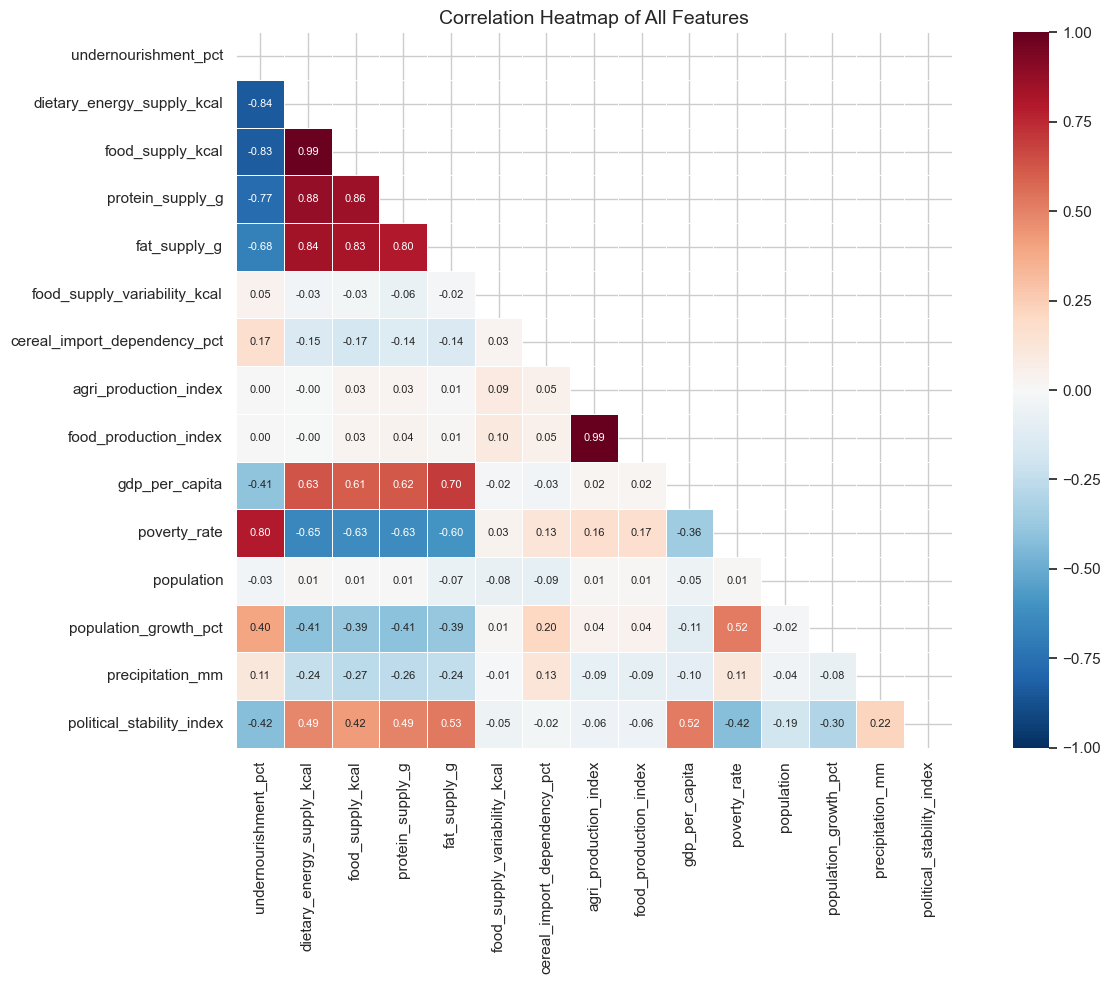

In [34]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != 'Year']

fig_path = FIGURES_DIR / 'step4_correlation_heatmap.png'

if fig_path.exists():
    print(f"Figure already exists, skipping: {fig_path.name}")
    from IPython.display import Image
    display(Image(str(fig_path)))
else:
    corr_matrix = df[numeric_cols].corr()
    fig, ax = plt.subplots(figsize=(14, 10))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

    sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
                cmap='RdBu_r', center=0, vmin=-1, vmax=1,
                square=True, linewidths=0.5, ax=ax,
                annot_kws={'size': 8})

    ax.set_title('Correlation Heatmap of All Features', fontsize=14)
    plt.tight_layout()
    plt.savefig(fig_path, bbox_inches='tight')
    plt.show()
    print("Saved ✅")

Figure already exists, skipping: step4_target_correlation.png


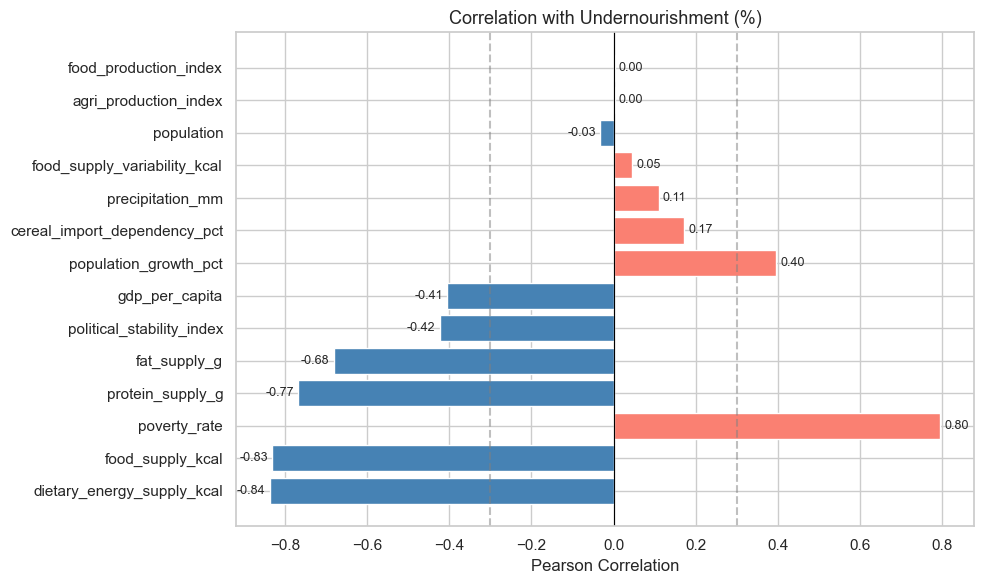


=== Feature Correlation with undernourishment_pct ===
dietary_energy_supply_kcal     -0.837
food_supply_kcal               -0.831
poverty_rate                    0.796
protein_supply_g               -0.769
fat_supply_g                   -0.682
political_stability_index      -0.424
gdp_per_capita                 -0.406
population_growth_pct           0.396
cereal_import_dependency_pct    0.171
precipitation_mm                0.110
food_supply_variability_kcal    0.045
population                     -0.033
agri_production_index           0.003
food_production_index           0.003
Name: undernourishment_pct, dtype: float64

Key findings:
- dietary_energy_supply_kcal (-0.84): Strongest negative predictor
- food_supply_kcal (-0.83): Near-identical to dietary_energy (r=0.99 between them)
- poverty_rate (+0.80): Strongest positive predictor
- agri/food_production_index (~0.00): Surprisingly uncorrelated with target
- Multicollinearity warning: food_supply_kcal & dietary_energy_supply_kcal (

In [35]:
fig_path = FIGURES_DIR / 'step4_target_correlation.png'

if fig_path.exists():
    print(f"Figure already exists, skipping: {fig_path.name}")
    from IPython.display import Image
    display(Image(str(fig_path)))
else:
    target_corr = df[numeric_cols].corr()['undernourishment_pct'].drop('undernourishment_pct')
    target_corr = target_corr.sort_values(key=abs, ascending=False)

    fig, ax = plt.subplots(figsize=(10, 6))
    colors = ['salmon' if v > 0 else 'steelblue' for v in target_corr.values]
    ax.barh(target_corr.index, target_corr.values, color=colors, edgecolor='white')
    ax.set_title('Correlation with Undernourishment (%)', fontsize=13)
    ax.set_xlabel('Pearson Correlation')
    ax.axvline(0, color='black', linewidth=0.8)
    ax.axvline(0.3, color='gray', linestyle='--', alpha=0.5)
    ax.axvline(-0.3, color='gray', linestyle='--', alpha=0.5)

    for i, v in enumerate(target_corr.values):
        ax.text(v + 0.01 if v > 0 else v - 0.01, i,
                f'{v:.2f}', va='center', ha='left' if v > 0 else 'right', fontsize=9)

    plt.tight_layout()
    plt.savefig(fig_path, bbox_inches='tight')
    plt.show()
    print("Saved ✅")

# Print ranking
target_corr = df[numeric_cols].corr()['undernourishment_pct'].drop('undernourishment_pct')
target_corr = target_corr.sort_values(key=abs, ascending=False)
print("\n=== Feature Correlation with undernourishment_pct ===")
print(target_corr.round(3))
print()
print("Key findings:")
print("- dietary_energy_supply_kcal (-0.84): Strongest negative predictor")
print("- food_supply_kcal (-0.83): Near-identical to dietary_energy (r=0.99 between them)")
print("- poverty_rate (+0.80): Strongest positive predictor")
print("- agri/food_production_index (~0.00): Surprisingly uncorrelated with target")
print("- Multicollinearity warning: food_supply_kcal & dietary_energy_supply_kcal (r=0.99)")

## Step 5 — Country & Regional Comparison

Identifying the highest-risk countries and comparing undernourishment rates across world regions.


Figure already exists, skipping: step5_top20_countries.png


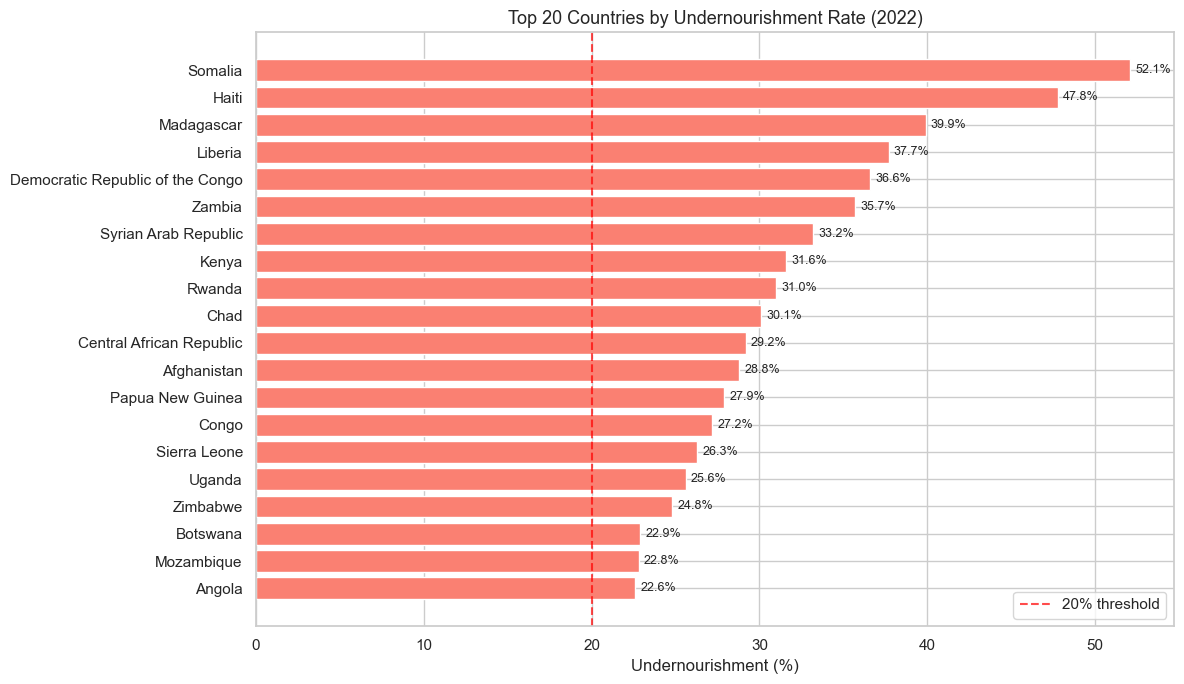

In [36]:
fig_path = FIGURES_DIR / 'step5_top20_countries.png'

if fig_path.exists():
    print(f"Figure already exists, skipping: {fig_path.name}")
    from IPython.display import Image
    display(Image(str(fig_path)))
else:
    df_latest = df[df['Year'] == 2022].copy()
    top20 = (df_latest[['Area', 'undernourishment_pct']]
             .dropna()
             .sort_values('undernourishment_pct', ascending=False)
             .head(20))

    fig, ax = plt.subplots(figsize=(12, 7))
    bars = ax.barh(top20['Area'], top20['undernourishment_pct'],
                   color='salmon', edgecolor='white')
    ax.set_title('Top 20 Countries by Undernourishment Rate (2022)', fontsize=13)
    ax.set_xlabel('Undernourishment (%)')
    ax.invert_yaxis()
    ax.axvline(20, color='red', linestyle='--', alpha=0.7, label='20% threshold')
    ax.legend()

    for bar, val in zip(bars, top20['undernourishment_pct']):
        ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}%', va='center', fontsize=9)

    plt.tight_layout()
    plt.savefig(fig_path, bbox_inches='tight')
    plt.show()
    print("Saved ✅")

Figure already exists, skipping: step5_region_comparison.png


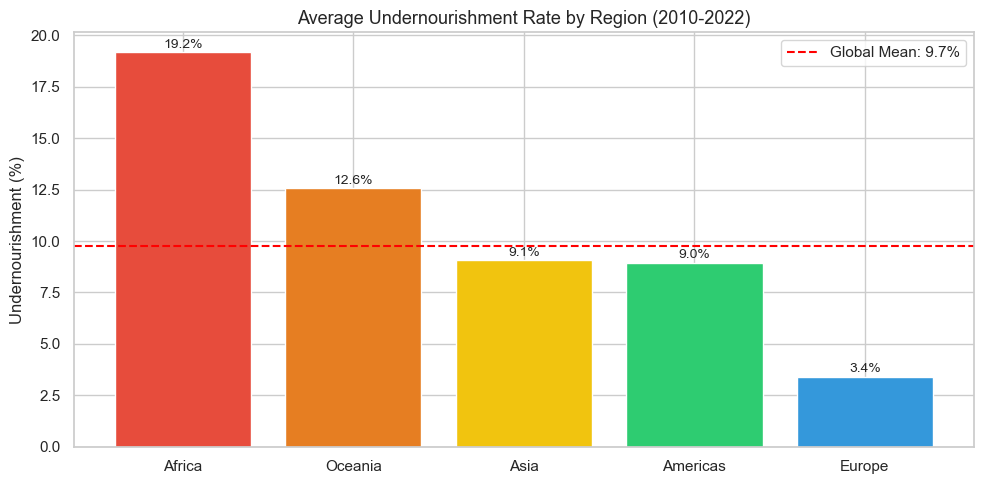

In [37]:
# Region mapping
region_map = {
    'AFG':'Asia','AGO':'Africa','ALB':'Europe','DZA':'Africa','ARG':'Americas',
    'ARM':'Asia','AUS':'Oceania','AUT':'Europe','AZE':'Asia','BDI':'Africa',
    'BEN':'Africa','BFA':'Africa','BGD':'Asia','BGR':'Europe','BLR':'Europe',
    'BLZ':'Americas','BOL':'Americas','BRA':'Americas','BTN':'Asia','BWA':'Africa',
    'CAF':'Africa','CHL':'Americas','CHN':'Asia','CIV':'Africa','CMR':'Africa',
    'COD':'Africa','COG':'Africa','COL':'Americas','COM':'Africa','CPV':'Africa',
    'CRI':'Americas','CUB':'Americas','DOM':'Americas','ECU':'Americas',
    'EGY':'Africa','ERI':'Africa','ETH':'Africa','FJI':'Oceania','GAB':'Africa',
    'GHA':'Africa','GIN':'Africa','GMB':'Africa','GNB':'Africa','GTM':'Americas',
    'GUY':'Americas','HND':'Americas','HTI':'Americas','IDN':'Asia','IND':'Asia',
    'IRN':'Asia','IRQ':'Asia','JAM':'Americas','JOR':'Asia','KAZ':'Asia',
    'KEN':'Africa','KGZ':'Asia','KHM':'Asia','LAO':'Asia','LBN':'Asia',
    'LBR':'Africa','LKA':'Asia','LSO':'Africa','MDG':'Africa','MDV':'Asia',
    'MEX':'Americas','MLI':'Africa','MOZ':'Africa','MRT':'Africa','MWI':'Africa',
    'MYS':'Asia','NAM':'Africa','NER':'Africa','NGA':'Africa','NIC':'Americas',
    'NPL':'Asia','PAK':'Asia','PAN':'Americas','PER':'Americas','PHL':'Asia',
    'PNG':'Oceania','PRY':'Americas','RWA':'Africa','SDN':'Africa','SEN':'Africa',
    'SLE':'Africa','SLV':'Americas','SOM':'Africa','SSD':'Africa','STP':'Africa',
    'SUR':'Americas','SWZ':'Africa','SYR':'Asia','TCD':'Africa','TGO':'Africa',
    'THA':'Asia','TJK':'Asia','TLS':'Asia','TTO':'Americas','TUN':'Africa',
    'TZA':'Africa','UGA':'Africa','URY':'Americas','UZB':'Asia','VEN':'Americas',
    'VNM':'Asia','YEM':'Asia','ZAF':'Africa','ZMB':'Africa','ZWE':'Africa',
}
df['region'] = df['iso3'].map(region_map)

region_colors = {
    'Africa': '#e74c3c', 'Asia': '#3498db', 'Americas': '#2ecc71',
    'Oceania': '#e67e22', 'Europe': '#9b59b6'
}

fig_path = FIGURES_DIR / 'step5_region_comparison.png'

if fig_path.exists():
    print(f"Figure already exists, skipping: {fig_path.name}")
    from IPython.display import Image
    display(Image(str(fig_path)))
else:
    region_avg = (df.groupby('region')['undernourishment_pct']
                  .mean().dropna().sort_values(ascending=False))

    fig, ax = plt.subplots(figsize=(10, 5))
    colors_region = [region_colors.get(r, 'gray') for r in region_avg.index]
    bars = ax.bar(region_avg.index, region_avg.values,
                  color=colors_region, edgecolor='white')
    ax.set_title('Average Undernourishment Rate by Region (2010-2022)', fontsize=13)
    ax.set_ylabel('Undernourishment (%)')
    ax.axhline(df['undernourishment_pct'].mean(), color='red',
               linestyle='--', label=f'Global Mean: {df["undernourishment_pct"].mean():.1f}%')
    ax.legend()

    for bar, val in zip(bars, region_avg.values):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.2,
                f'{val:.1f}%', ha='center', fontsize=10)

    plt.tight_layout()
    plt.savefig(fig_path, bbox_inches='tight')
    plt.show()
    print("Saved ✅")

In [38]:
import plotly.express as px

fig_path = FIGURES_DIR / 'step5_world_map.html'

if fig_path.exists():
    print(f"Figure already exists, skipping: {fig_path.name}")
else:
    df_map = df[df['Year'] == 2022][['iso3', 'Area', 'undernourishment_pct']].dropna()

    fig = px.choropleth(
        df_map,
        locations='iso3',
        color='undernourishment_pct',
        hover_name='Area',
        hover_data={'undernourishment_pct': ':.1f', 'iso3': False},
        color_continuous_scale='YlOrRd',
        range_color=[0, 50],
        title='Undernourishment Rate by Country (2022)',
        labels={'undernourishment_pct': 'Undernourishment (%)'}
    )
    fig.update_layout(
        geo=dict(showframe=False, showcoastlines=True),
        title_font_size=16,
        margin=dict(l=0, r=0, t=50, b=0)
    )
    fig.write_html(str(fig_path))
    fig.show()
    print("Saved as HTML ✅")

print("World map saved to outputs/figures/step5_world_map.html")
print("Open in browser for interactive exploration.")

Figure already exists, skipping: step5_world_map.html
World map saved to outputs/figures/step5_world_map.html
Open in browser for interactive exploration.


## Step 6 — Time Series Trends (2010–2022)

Analyzing global and regional trends in undernourishment over time.


Figure already exists, skipping: step6_global_trend.png


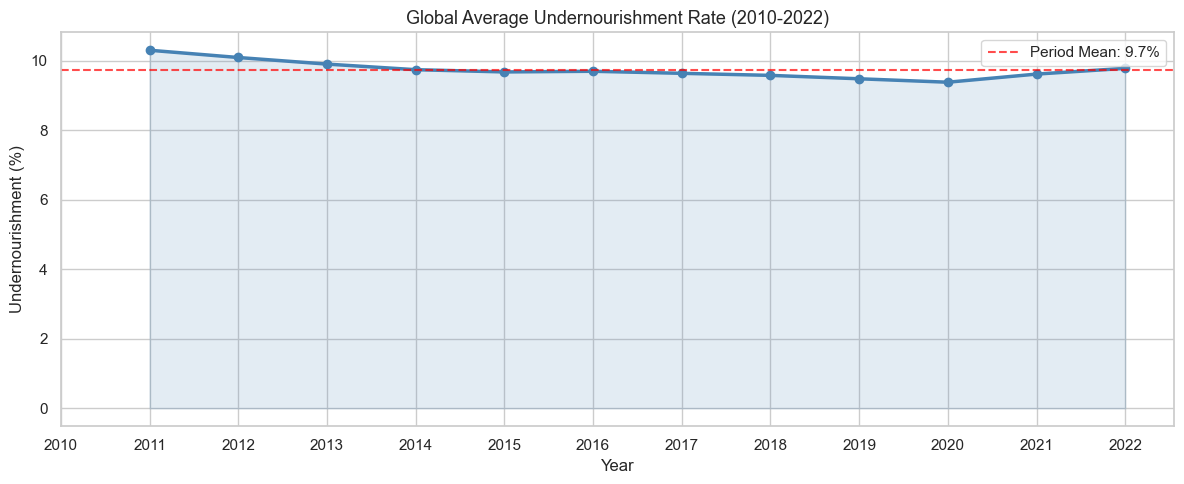

In [39]:
fig_path = FIGURES_DIR / 'step6_global_trend.png'

if fig_path.exists():
    print(f"Figure already exists, skipping: {fig_path.name}")
    from IPython.display import Image
    display(Image(str(fig_path)))
else:
    yearly_global = df.groupby('Year')['undernourishment_pct'].mean()

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(yearly_global.index, yearly_global.values,
            color='steelblue', linewidth=2.5, marker='o', markersize=6)
    ax.fill_between(yearly_global.index, yearly_global.values, alpha=0.15, color='steelblue')
    ax.set_title('Global Average Undernourishment Rate (2010-2022)', fontsize=13)
    ax.set_xlabel('Year')
    ax.set_ylabel('Undernourishment (%)')
    ax.set_xticks(yearly_global.index)
    ax.axhline(yearly_global.mean(), color='red', linestyle='--',
               alpha=0.7, label=f'Period Mean: {yearly_global.mean():.1f}%')
    ax.legend()

    plt.tight_layout()
    plt.savefig(fig_path, bbox_inches='tight')
    plt.show()
    print("Saved ✅")

Figure already exists, skipping: step6_region_trend.png


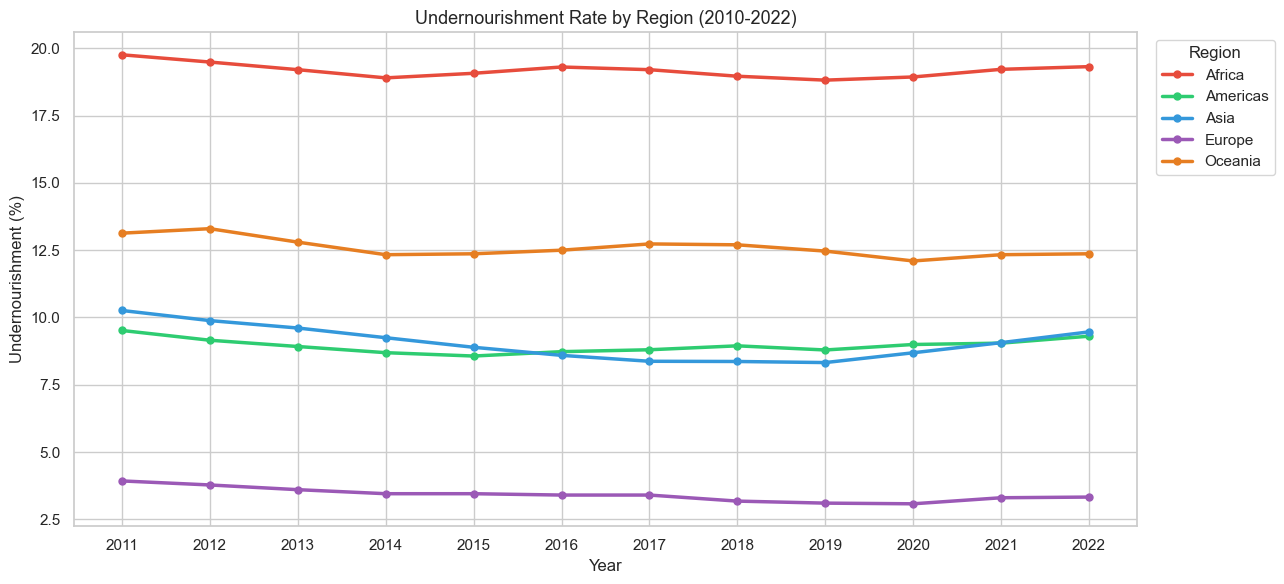


Key findings:
- Global rate slightly improved 2011→2020 (10.3% → 9.4%)
- Worsened again in 2021-2022, likely due to COVID-19 supply chain disruption
- Africa remains flat at ~19%, showing no meaningful improvement
- Europe consistently lowest at ~3%


In [40]:
fig_path = FIGURES_DIR / 'step6_region_trend.png'

if fig_path.exists():
    print(f"Figure already exists, skipping: {fig_path.name}")
    from IPython.display import Image
    display(Image(str(fig_path)))
else:
    yearly_region = (df.groupby(['Year', 'region'])['undernourishment_pct']
                     .mean().reset_index().dropna())

    fig, ax = plt.subplots(figsize=(13, 6))
    for region, group in yearly_region.groupby('region'):
        color = region_colors.get(region, 'gray')
        ax.plot(group['Year'], group['undernourishment_pct'],
                label=region, color=color, linewidth=2.5, marker='o', markersize=5)

    ax.set_title('Undernourishment Rate by Region (2010-2022)', fontsize=13)
    ax.set_xlabel('Year')
    ax.set_ylabel('Undernourishment (%)')
    ax.set_xticks(yearly_region['Year'].unique())
    ax.legend(title='Region', bbox_to_anchor=(1.01, 1), loc='upper left')

    plt.tight_layout()
    plt.savefig(fig_path, bbox_inches='tight')
    plt.show()
    print("Saved ✅")

print()
print("Key findings:")
print("- Global rate slightly improved 2011→2020 (10.3% → 9.4%)")
print("- Worsened again in 2021-2022, likely due to COVID-19 supply chain disruption")
print("- Africa remains flat at ~19%, showing no meaningful improvement")
print("- Europe consistently lowest at ~3%")

## Step 7 — Feature vs Target Scatter Plots

Visualizing the relationship between key features and the target variable, colored by region.


Figure already exists, skipping: step7_scatter_plots.png


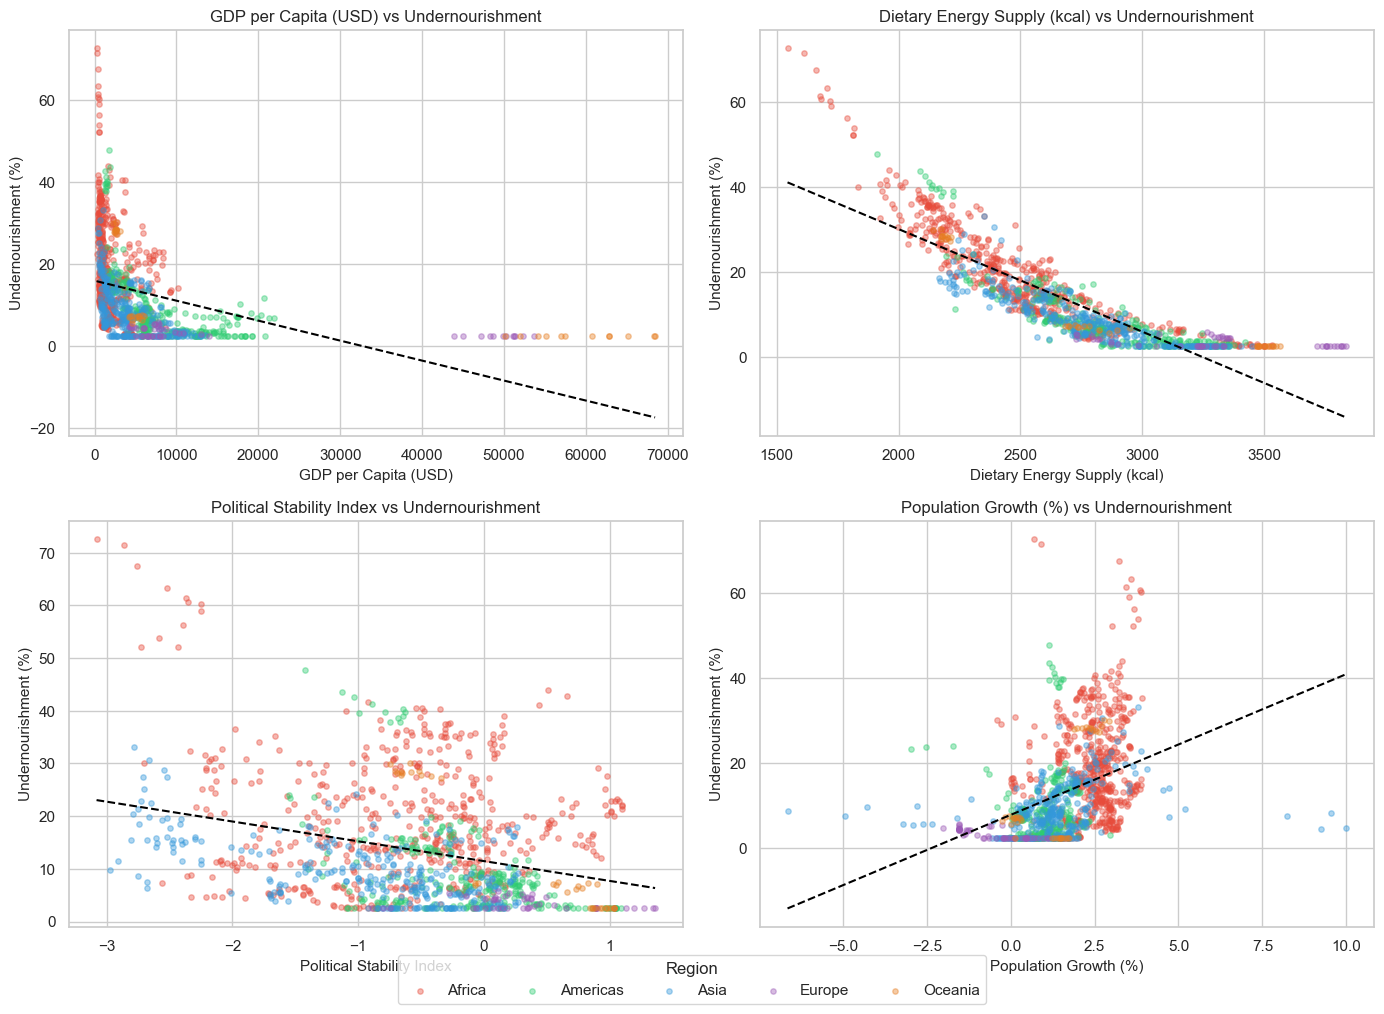


Key findings:
- GDP per capita: Strong non-linear relationship → log(GDP) recommended for modeling
- Dietary energy supply: Clearest linear negative relationship
- Political stability: Moderate negative, high variance in Africa
- Population growth: Positive relationship — fast-growing countries tend to be higher risk


In [41]:
fig_path = FIGURES_DIR / 'step7_scatter_plots.png'

if fig_path.exists():
    print(f"Figure already exists, skipping: {fig_path.name}")
    from IPython.display import Image
    display(Image(str(fig_path)))
else:
    features = [
        ('gdp_per_capita', 'GDP per Capita (USD)'),
        ('dietary_energy_supply_kcal', 'Dietary Energy Supply (kcal)'),
        ('political_stability_index', 'Political Stability Index'),
        ('population_growth_pct', 'Population Growth (%)'),
    ]

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()

    for i, (col, label) in enumerate(features):
        plot_df = df[[col, 'undernourishment_pct', 'region']].dropna()

        for region, group in plot_df.groupby('region'):
            color = region_colors.get(region, 'gray')
            axes[i].scatter(group[col], group['undernourishment_pct'],
                           alpha=0.4, s=15, color=color, label=region)

        from numpy.polynomial.polynomial import polyfit
        x = plot_df[col].values
        y = plot_df['undernourishment_pct'].values
        b, m = polyfit(x, y, 1)
        x_line = np.linspace(x.min(), x.max(), 100)
        axes[i].plot(x_line, m * x_line + b, color='black', linewidth=1.5, linestyle='--')

        axes[i].set_xlabel(label, fontsize=11)
        axes[i].set_ylabel('Undernourishment (%)', fontsize=11)
        axes[i].set_title(f'{label} vs Undernourishment', fontsize=12)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, title='Region',
               loc='lower center', ncol=5, bbox_to_anchor=(0.5, -0.02))

    plt.tight_layout()
    plt.savefig(fig_path, bbox_inches='tight')
    plt.show()
    print("Saved ✅")

print()
print("Key findings:")
print("- GDP per capita: Strong non-linear relationship → log(GDP) recommended for modeling")
print("- Dietary energy supply: Clearest linear negative relationship")
print("- Political stability: Moderate negative, high variance in Africa")
print("- Population growth: Positive relationship — fast-growing countries tend to be higher risk")

## Deep Dive 1 — Outlier Impact Analysis

Assessing how outlier countries (undernourishment > 30.5%) affect feature correlations.


In [42]:
# Define outliers using IQR method
Q1 = df['undernourishment_pct'].quantile(0.25)
Q3 = df['undernourishment_pct'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

print(f"Q1: {Q1:.1f}% | Q3: {Q3:.1f}% | IQR: {IQR:.1f} | Upper bound: {upper_bound:.1f}%")

outliers = df[df['undernourishment_pct'] > upper_bound]['Area'].unique()
print(f"\nOutlier countries ({len(outliers)}):")
print(', '.join(sorted(outliers)))

df_no_outlier = df[df['undernourishment_pct'] <= upper_bound].copy()
print(f"\nRows before: {len(df)} | After removing outliers: {len(df_no_outlier)}")

Q1: 2.5% | Q3: 13.7% | IQR: 11.2 | Upper bound: 30.5%

Outlier countries (15):
Central African Republic, Congo, Democratic People's Republic of Korea, Democratic Republic of the Congo, Haiti, Kenya, Liberia, Madagascar, Mozambique, Rwanda, Somalia, Syrian Arab Republic, Uganda, Zambia, Zimbabwe

Rows before: 2599 | After removing outliers: 1900


Figure already exists, skipping: deep1_outlier_correlation.png


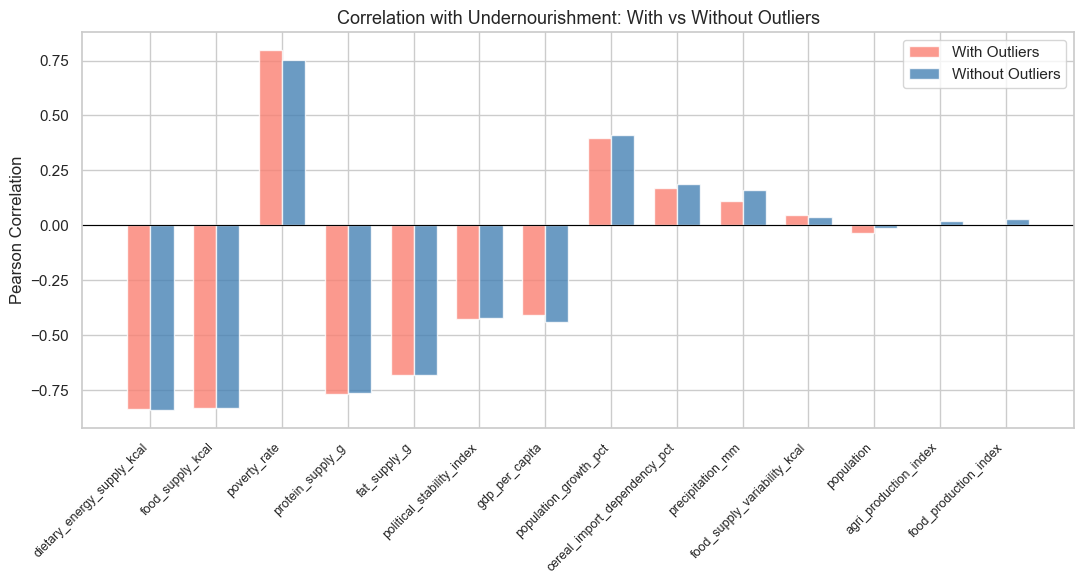


Conclusion: Key correlations are robust to outlier removal.
Main model will use full dataset; outlier countries noted as special high-risk group.


In [43]:
fig_path = FIGURES_DIR / 'deep1_outlier_correlation.png'

if fig_path.exists():
    print(f"Figure already exists, skipping: {fig_path.name}")
    from IPython.display import Image
    display(Image(str(fig_path)))
else:
    corr_before = df[numeric_cols].corr()['undernourishment_pct'].drop('undernourishment_pct')
    corr_after = df_no_outlier[numeric_cols].corr()['undernourishment_pct'].drop('undernourishment_pct')

    compare_df = pd.DataFrame({
        'With Outliers': corr_before,
        'Without Outliers': corr_after
    }).sort_values('With Outliers', key=abs, ascending=False)

    fig, ax = plt.subplots(figsize=(11, 6))
    x = np.arange(len(compare_df))
    width = 0.35

    ax.bar(x - width/2, compare_df['With Outliers'], width,
           label='With Outliers', color='salmon', alpha=0.8)
    ax.bar(x + width/2, compare_df['Without Outliers'], width,
           label='Without Outliers', color='steelblue', alpha=0.8)

    ax.set_xticks(x)
    ax.set_xticklabels(compare_df.index, rotation=45, ha='right', fontsize=9)
    ax.set_title('Correlation with Undernourishment: With vs Without Outliers', fontsize=13)
    ax.set_ylabel('Pearson Correlation')
    ax.axhline(0, color='black', linewidth=0.8)
    ax.legend()

    plt.tight_layout()
    plt.savefig(fig_path, bbox_inches='tight')
    plt.show()
    print("Saved ✅")

print()
print("Conclusion: Key correlations are robust to outlier removal.")
print("Main model will use full dataset; outlier countries noted as special high-risk group.")

## Deep Dive 2 — Country Risk Clustering

Grouping countries into distinct risk profiles using K-Means clustering on 2022 data.


In [44]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA

cluster_features = [
    'undernourishment_pct', 'dietary_energy_supply_kcal', 'gdp_per_capita',
    'political_stability_index', 'population_growth_pct', 'precipitation_mm'
]

df_cluster = df[df['Year'] == 2022][['iso3', 'Area', 'region'] + cluster_features].copy()
df_cluster = df_cluster.dropna(subset=['undernourishment_pct'])

imputer = SimpleImputer(strategy='median')
X = imputer.fit_transform(df_cluster[cluster_features])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Clustering dataset shape: {X_scaled.shape}")

Clustering dataset shape: (168, 6)


Figure already exists, skipping: deep2_elbow.png


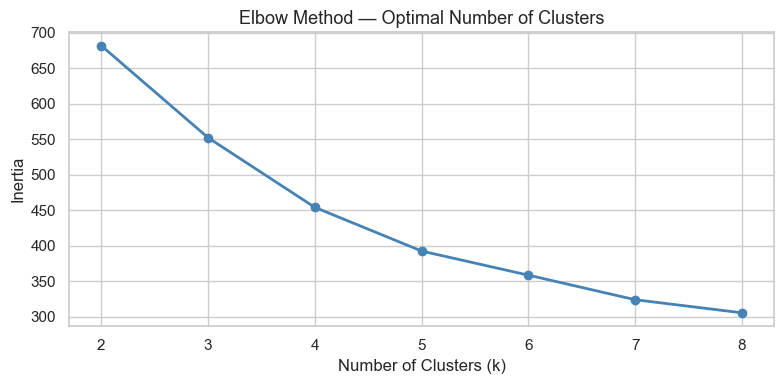

Selected k=4: Elbow at k=4-5; 4 clusters provides interpretable risk tiers.


In [45]:
fig_path = FIGURES_DIR / 'deep2_elbow.png'

if fig_path.exists():
    print(f"Figure already exists, skipping: {fig_path.name}")
    from IPython.display import Image
    display(Image(str(fig_path)))
else:
    inertias = []
    K_range = range(2, 9)
    for k in K_range:
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        km.fit(X_scaled)
        inertias.append(km.inertia_)

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(K_range, inertias, marker='o', color='steelblue', linewidth=2)
    ax.set_title('Elbow Method — Optimal Number of Clusters', fontsize=13)
    ax.set_xlabel('Number of Clusters (k)')
    ax.set_ylabel('Inertia')
    ax.set_xticks(list(K_range))
    plt.tight_layout()
    plt.savefig(fig_path, bbox_inches='tight')
    plt.show()
    print("Saved ✅")

print("Selected k=4: Elbow at k=4-5; 4 clusters provides interpretable risk tiers.")

In [46]:
import os
os.environ['OMP_NUM_THREADS'] = '1'  # Suppress KMeans memory leak warning on Windows

km = KMeans(n_clusters=4, random_state=42, n_init=10)
df_cluster['cluster'] = km.fit_predict(X_scaled)

cluster_profile = df_cluster.groupby('cluster')[cluster_features].mean().round(1)
print("=== Cluster Profiles ===")
print(cluster_profile)

cluster_labels = {
    0: '🔴 High Risk',
    1: '🔵 Low Risk',
    2: '🟢 Very Low Risk (Advanced)',
    3: '🟠 Medium Risk'
}

print("\n=== Cluster Interpretation ===")
for c, label in cluster_labels.items():
    countries = sorted(df_cluster[df_cluster['cluster'] == c]['Area'].tolist())
    print(f"\n{label} — {len(countries)} countries:")
    print(', '.join(countries))

=== Cluster Profiles ===
         undernourishment_pct  dietary_energy_supply_kcal  gdp_per_capita  \
cluster                                                                     
0                        21.7                      2454.9          2174.3   
1                         3.8                      3216.6         14505.3   
2                         2.6                      3539.7         60045.2   
3                         9.3                      2822.1          6211.4   

         political_stability_index  population_growth_pct  precipitation_mm  
cluster                                                                      
0                             -1.0                    2.2             820.0  
1                              0.0                    0.1             740.3  
2                              0.6                    1.7             811.1  
3                             -0.1                    1.1            2239.9  

=== Cluster Interpretation ===

🔴 High Risk

c:\Users\kotae\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.



Figure already exists, skipping: deep2_clusters.png


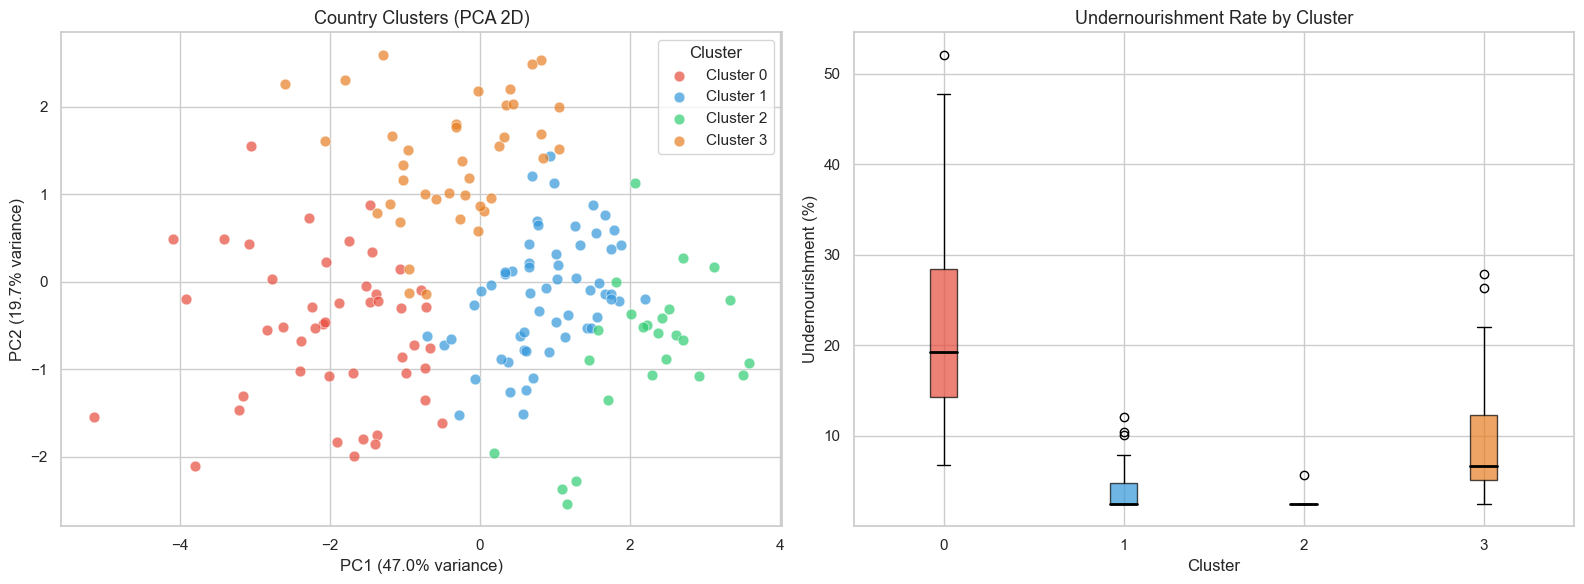

In [47]:
fig_path = FIGURES_DIR / 'deep2_clusters.png'

if fig_path.exists():
    print(f"Figure already exists, skipping: {fig_path.name}")
    from IPython.display import Image
    display(Image(str(fig_path)))
else:
    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X_scaled)
    df_cluster['pca1'] = X_pca[:, 0]
    df_cluster['pca2'] = X_pca[:, 1]

    cluster_colors_map = {0: '#e74c3c', 1: '#3498db', 2: '#2ecc71', 3: '#e67e22'}

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    for c, group in df_cluster.groupby('cluster'):
        axes[0].scatter(group['pca1'], group['pca2'],
                        color=cluster_colors_map[c], label=cluster_labels[c],
                        alpha=0.7, s=60, edgecolors='white', linewidth=0.5)

    axes[0].set_title('Country Clusters (PCA 2D)', fontsize=13)
    axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
    axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
    axes[0].legend(title='Cluster', fontsize=8)

    for c in sorted(df_cluster['cluster'].unique()):
        data = df_cluster[df_cluster['cluster'] == c]['undernourishment_pct']
        axes[1].boxplot(data, positions=[c], patch_artist=True,
                        boxprops=dict(facecolor=cluster_colors_map[c], alpha=0.7),
                        medianprops=dict(color='black', linewidth=2))

    axes[1].set_title('Undernourishment Rate by Cluster', fontsize=13)
    axes[1].set_xlabel('Cluster')
    axes[1].set_ylabel('Undernourishment (%)')
    axes[1].set_xticks([0, 1, 2, 3])

    plt.tight_layout()
    plt.savefig(fig_path, bbox_inches='tight')
    plt.show()
    print("Saved ✅")

In [48]:
df_cluster['cluster_label'] = df_cluster['cluster'].map(cluster_labels)

fig_path_html = FIGURES_DIR / 'deep2_cluster_map.html'

if fig_path_html.exists():
    print(f"Figure already exists, skipping: {fig_path_html.name}")
else:
    fig = px.choropleth(
        df_cluster,
        locations='iso3',
        color='cluster_label',
        hover_name='Area',
        hover_data={'undernourishment_pct': ':.1f', 'gdp_per_capita': ':.0f', 'iso3': False},
        color_discrete_map={
            '🔴 High Risk': 'red',
            '🟠 Medium Risk': 'orange',
            '🔵 Low Risk': 'royalblue',
            '🟢 Very Low Risk (Advanced)': 'green'
        },
        title='Country Risk Clusters (2022)',
        labels={'cluster_label': 'Risk Cluster'}
    )
    fig.update_layout(
        geo=dict(showframe=False, showcoastlines=True),
        title_font_size=16,
        margin=dict(l=0, r=0, t=50, b=0)
    )
    fig.write_html(str(fig_path_html))
    fig.show()
    print("Saved as HTML ✅")

print("Cluster map saved to outputs/figures/deep2_cluster_map.html")

Figure already exists, skipping: deep2_cluster_map.html
Cluster map saved to outputs/figures/deep2_cluster_map.html


## Deep Dive 3 — COVID-19 Impact Analysis (2019→2022)

Assessing how the pandemic affected undernourishment rates globally and by region.


In [49]:
covid_years = [2019, 2020, 2021, 2022]
df_covid = df[df['Year'].isin(covid_years)].copy()

covid_global = df_covid.groupby('Year')[['undernourishment_pct',
                                          'dietary_energy_supply_kcal',
                                          'gdp_per_capita',
                                          'food_supply_kcal']].mean().round(2)
print("=== Global Average by Year (COVID Period) ===")
print(covid_global)

change = ((covid_global.loc[2022] - covid_global.loc[2019]) /
           covid_global.loc[2019] * 100).round(2)
print("\n=== Change 2019→2022 (%) ===")
print(change)

=== Global Average by Year (COVID Period) ===
      undernourishment_pct  dietary_energy_supply_kcal  gdp_per_capita  \
Year                                                                     
2019                  9.49                     2938.88        15775.12   
2020                  9.39                     2947.14        14624.12   
2021                  9.62                     2954.27        16813.27   
2022                  9.79                     2967.58        17521.41   

      food_supply_kcal  
Year                    
2019           2954.14  
2020           2965.17  
2021           2973.11  
2022           2982.47  

=== Change 2019→2022 (%) ===
undernourishment_pct           3.16
dietary_energy_supply_kcal     0.98
gdp_per_capita                11.07
food_supply_kcal               0.96
dtype: float64


Figure already exists, skipping: deep3_covid_impact.png


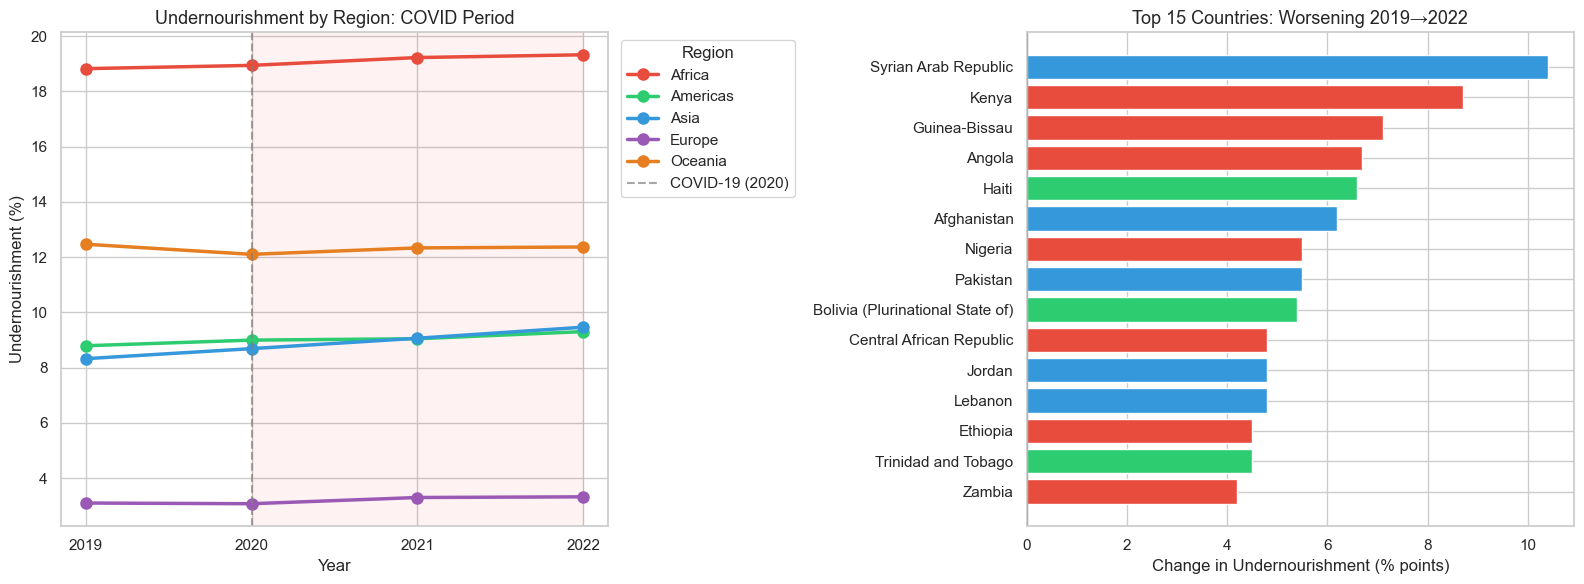


Key findings:
- Global rate temporarily improved in 2020, then worsened through 2022
- GDP recovered (+11%) but undernourishment still rose — recovery benefits didn't reach the poor
- Syria (+10.5pp), Kenya (+8.5pp): Conflict + COVID compounded effects
- Africa: No improvement across entire period


In [50]:
fig_path = FIGURES_DIR / 'deep3_covid_impact.png'

if fig_path.exists():
    print(f"Figure already exists, skipping: {fig_path.name}")
    from IPython.display import Image
    display(Image(str(fig_path)))
else:
    covid_region = (df_covid.groupby(['Year', 'region'])['undernourishment_pct']
                    .mean().reset_index().dropna())

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    for region, group in covid_region.groupby('region'):
        color = region_colors.get(region, 'gray')
        axes[0].plot(group['Year'], group['undernourishment_pct'],
                     label=region, color=color, linewidth=2.5, marker='o', markersize=8)

    axes[0].axvline(2020, color='gray', linestyle='--', alpha=0.7, label='COVID-19 (2020)')
    axes[0].axvspan(2020, 2022, alpha=0.05, color='red')
    axes[0].set_title('Undernourishment by Region: COVID Period', fontsize=13)
    axes[0].set_xlabel('Year')
    axes[0].set_ylabel('Undernourishment (%)')
    axes[0].set_xticks(covid_years)
    axes[0].legend(title='Region', bbox_to_anchor=(1.01, 1), loc='upper left')

    df_2019 = df[df['Year'] == 2019][['iso3', 'Area', 'region', 'undernourishment_pct']].set_index('iso3')
    df_2022 = df[df['Year'] == 2022][['iso3', 'Area', 'region', 'undernourishment_pct']].set_index('iso3')
    df_change = df_2019.join(df_2022, lsuffix='_2019', rsuffix='_2022').dropna()
    df_change['change'] = df_change['undernourishment_pct_2022'] - df_change['undernourishment_pct_2019']
    worst = df_change.nlargest(15, 'change')

    colors_bar = [region_colors.get(r, 'gray') for r in worst['region_2019']]
    axes[1].barh(worst['Area_2019'], worst['change'], color=colors_bar, edgecolor='white')
    axes[1].set_title('Top 15 Countries: Worsening 2019→2022', fontsize=13)
    axes[1].set_xlabel('Change in Undernourishment (% points)')
    axes[1].axvline(0, color='black', linewidth=0.8)
    axes[1].invert_yaxis()

    plt.tight_layout()
    plt.savefig(fig_path, bbox_inches='tight')
    plt.show()
    print("Saved ✅")

print()
print("Key findings:")
print("- Global rate temporarily improved in 2020, then worsened through 2022")
print("- GDP recovered (+11%) but undernourishment still rose — recovery benefits didn't reach the poor")
print("- Syria (+10.5pp), Kenya (+8.5pp): Conflict + COVID compounded effects")
print("- Africa: No improvement across entire period")

## Summary of Key Findings

### 1. Highest-Risk Countries (2022)
| Rank | Country | Undernourishment |
|------|---------|-----------------|
| 1 | Somalia | 52.1% |
| 2 | Haiti | 47.8% |
| 3 | Madagascar | 39.9% |
| 4 | Liberia | 37.7% |
| 5 | DR Congo | 36.6% |

### 2. Strongest Predictors of Undernourishment
| Feature | Correlation | Direction |
|---------|------------|-----------|
| dietary_energy_supply_kcal | -0.84 | More food → less risk |
| food_supply_kcal | -0.83 | (highly correlated with above) |
| poverty_rate | +0.80 | More poverty → more risk |
| protein_supply_g | -0.77 | More protein → less risk |
| political_stability_index | -0.42 | More stability → less risk |
| gdp_per_capita | -0.41 | Higher GDP → less risk (non-linear) |

### 3. Regional Patterns
- **Africa**: Persistently highest risk (~19%), no meaningful improvement 2010–2022
- **Oceania**: Second highest (~12.6%), driven by Papua New Guinea
- **Europe**: Lowest risk (~3.4%), consistently improving

### 4. Risk Clusters (2022)
- 🔴 **High Risk** (46 countries): Sub-Saharan Africa + conflict zones
- 🟠 **Medium Risk** (39 countries): Southeast Asia, Central America
- 🔵 **Low Risk** (58 countries): Eastern Europe, Middle-income Americas
- 🟢 **Very Low Risk** (25 countries): Western Europe, North America, Gulf states

### 5. COVID-19 Impact
- 2020: Brief improvement (supply chains, reduced food waste)
- 2021–2022: Worsening due to supply chain disruption and inflation
- Most affected: Syria (+10.5pp), Kenya (+8.5pp), Guinea-Bissau (+7pp)

### 6. Modeling Notes for Phase 4
- Use `log(1 + undernourishment_pct)` as target (strong right skew)
- Use `log(gdp_per_capita)` as feature (non-linear relationship)
- Drop `poverty_rate` (60% missing) or use as secondary model
- Choose one of `food_supply_kcal` / `dietary_energy_supply_kcal` (r=0.99)
- Choose one of `agri_production_index` / `food_production_index` (r=0.99)
